# Students' Academic Performance Prediction

## Introduction

This project focuses on analysing student academic performance and using machine learning techniques to predict students' performance classes. The dataset contains information related to students' academic participation, attendance, parental involvement, demographic details, and other learning-related factors.

The analysis begins with data inspection and exploratory analysis to understand the structure of the dataset and identify patterns in student performance. The data is then prepared for machine learning by separating the target variable, encoding categorical features, scaling numerical features, and dividing the dataset into training and testing sets.

Two classification models, Logistic Regression and Decision Tree, are developed and evaluated. Their performance is compared using accuracy, classification reports, and confusion matrices to determine which model performs better on the given dataset.

## Objective

The main objectives of this project are:

- To explore and understand the Student Academic Performance dataset.
- To identify important numerical and categorical features.
- To prepare the data for machine learning classification.
- To build a Logistic Regression model for predicting student performance.
- To build a Decision Tree model for comparison.
- To evaluate both models using appropriate classification metrics.
- To compare the models and identify the better-performing approach.

## 1. Dataset Loading and Initial Inspection

The dataset is loaded into a pandas DataFrame so that its structure and contents can be examined. The initial inspection helps identify the number of observations, available variables, data types, and the target variable that will be used for classification.

The first few records are displayed to get a basic understanding of the information contained in the dataset.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("xAPI-Edu-Data.csv")

In [3]:
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [4]:
df.shape

(480, 17)

### Observation

The dataset contains 480 student records and 17 columns, including demographic, academic, participation, and performance information.

In [5]:
df.columns

Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

## 2. Missing Value Analysis

Missing values can affect both exploratory analysis and machine learning models. Therefore, the number of missing values in each column is checked before continuing with the analysis.

The result is used to determine whether any additional missing-value treatment is required.

In [7]:
df.isnull().sum()

,0
gender,0
NationalITy,0
PlaceofBirth,0
StageID,0
GradeID,0
SectionID,0
Topic,0
Semester,0
Relation,0
raisedhands,0


### Observation

The missing-value check shows that all columns contain zero missing values. Therefore, no missing-value imputation or row removal is required for this dataset.

## 3. Distribution of Academic Performance Classes

The target variable `Class` represents the academic performance category of each student. Its frequency distribution is examined to understand how the observations are divided among the three performance classes.

This is important before model building because it gives an initial view of the distribution of the target categories.

In [8]:
df["Class"].value_counts()

,count
Class,
M,211
H,142
L,127


### Observation

The dataset contains three academic performance classes: H, L, and M. Class M has the largest number of observations, followed by H and L.

## 4. Understanding Feature Values

The unique values of the variables are examined to understand the categories and ranges present in the dataset. This helps distinguish categorical variables from numerical variables and provides a clearer idea of how the information is represented.

In [9]:
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique())


gender:
['M' 'F']

NationalITy:
['KW' 'lebanon' 'Egypt' 'SaudiArabia' 'USA' 'Jordan' 'venzuela' 'Iran'
 'Tunis' 'Morocco' 'Syria' 'Palestine' 'Iraq' 'Lybia']

PlaceofBirth:
['KuwaIT' 'lebanon' 'Egypt' 'SaudiArabia' 'USA' 'Jordan' 'venzuela' 'Iran'
 'Tunis' 'Morocco' 'Syria' 'Iraq' 'Palestine' 'Lybia']

StageID:
['lowerlevel' 'MiddleSchool' 'HighSchool']

GradeID:
['G-04' 'G-07' 'G-08' 'G-06' 'G-05' 'G-09' 'G-12' 'G-11' 'G-10' 'G-02']

SectionID:
['A' 'B' 'C']

Topic:
['IT' 'Math' 'Arabic' 'Science' 'English' 'Quran' 'Spanish' 'French'
 'History' 'Biology' 'Chemistry' 'Geology']

Semester:
['F' 'S']

Relation:
['Father' 'Mum']

raisedhands:
[ 15  20  10  30  40  42  35  50  12  70  19   5  62  36  55  69  60   2
   0   8  25  75   4  45  14  33   7  13  29  39  49  16  28  27  21  80
  17  65  22  11   1   3 100   6  90  77  24  66  23  82  72  51  85  87
  95  81  53  92  83  67  96  57  73   9  32  52  59  61  79  18  74  97
  41  71  98  78  89  88  86  76  99  84]

VisITedResources

### Observation

The dataset contains both categorical and numerical variables. The categorical variables include student demographics, educational stage, subject, semester, parental information, and absence category, while the participation-related variables contain numerical values.

## 5. Numerical Feature Analysis

Four numerical variables are examined in greater detail: raised hands, visited resources, announcements viewed, and discussion.

Descriptive statistics are calculated to understand the central tendency and spread of these variables, including their mean, standard deviation, minimum, quartiles, and maximum values.

In [10]:
numeric_features = [
      "raisedhands",
          "VisITedResources",
              "AnnouncementsView",
                  "Discussion"
                  ]

df[numeric_features].describe()


,raisedhands,VisITedResources,AnnouncementsView,Discussion
count,480.000000,480.000000,480.000000,480.000000
mean,46.775000,54.797917,37.918750,43.283333
std,30.779223,33.080007,26.611244,27.637735
min,0.000000,0.000000,0.000000,1.000000
25%,15.750000,20.000000,14.000000,20.000000
50%,50.000000,65.000000,33.000000,39.000000
75%,75.000000,84.000000,58.000000,70.000000
max,100.000000,99.000000,98.000000,99.000000


### Numerical Features by Performance Class

The average values of the numerical participation features are calculated separately for each academic performance class. This allows the participation patterns of H, L, and M students to be compared.

In [11]:
df.groupby("Class")[numeric_features].mean()

,raisedhands,VisITedResources,AnnouncementsView,Discussion
Class,,,,
H,70.288732,78.746479,53.380282,53.661972
L,16.889764,18.322835,15.574803,30.834646
M,48.938389,60.635071,40.962085,43.791469


### Observation

The class-wise averages show noticeable differences in participation. In particular, students in the H class have higher average values for raised hands, visited resources, announcements viewed, and discussion compared with the L class. The M class generally falls between the H and L groups.

## 6. Visual Analysis of Numerical Features

Graphs are used to make the differences between academic performance classes easier to interpret. The first visualization compares the average number of raised hands across the three performance classes.

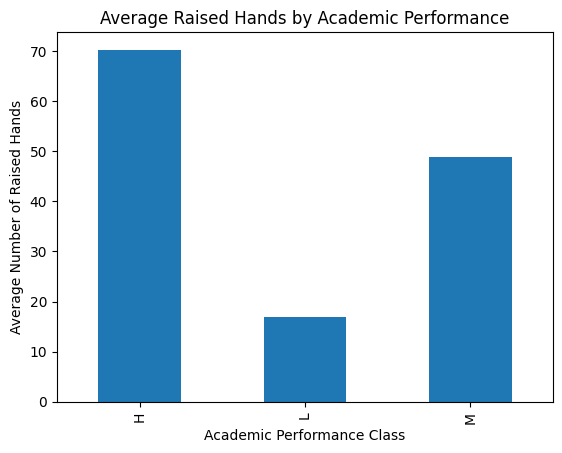

In [12]:
import matplotlib.pyplot as plt

df.groupby("Class")["raisedhands"].mean().plot(kind="bar")

plt.title("Average Raised Hands by Academic Performance")
plt.xlabel("Academic Performance Class")
plt.ylabel("Average Number of Raised Hands")
plt.show()

### Observation

The average number of raised hands differs noticeably between the three performance classes, with the H class showing the highest average and the L class showing the lowest.

### Comparison of Participation Measures

The four numerical participation measures are compared together to examine whether similar patterns appear across different forms of student engagement.

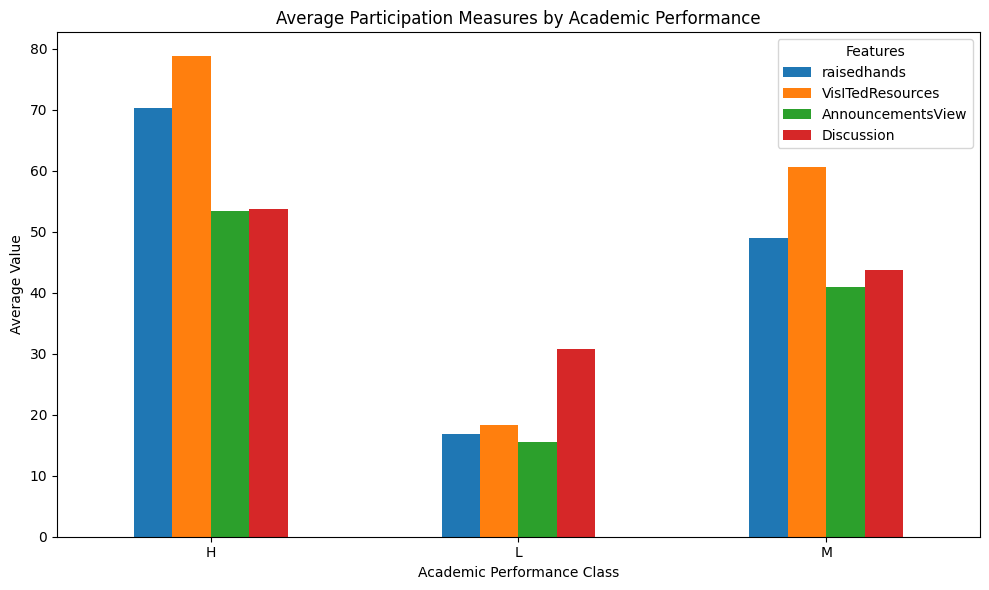

In [13]:
class_means = df.groupby("Class")[numeric_features].mean()

class_means.plot(kind="bar", figsize=(10, 6))

plt.title("Average Participation Measures by Academic Performance")
plt.xlabel("Academic Performance Class")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Features")
plt.tight_layout()
plt.show()

### Observation

The comparison shows that students in the H class generally have higher average participation values across the four numerical measures, while the L class has the lowest values for most measures. The M class generally falls between the two.

### Distribution of Numerical Features

Box plots are used to examine the distribution of each numerical feature across the three academic performance classes. They provide a visual comparison of the spread, central values, and possible outlying observations.

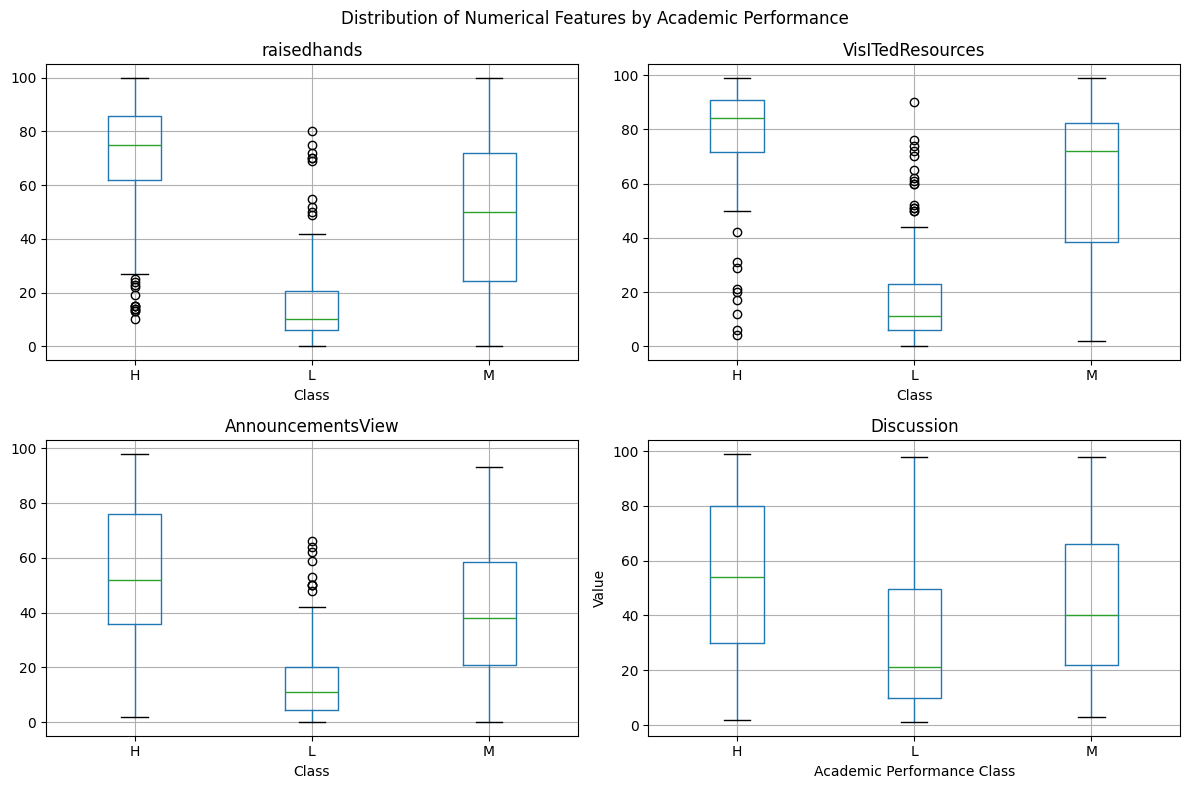

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), numeric_features):
         df.boxplot(column=feature, by="Class", ax=ax)
ax.set_title(feature)
ax.set_xlabel("Academic Performance Class")
ax.set_ylabel("Value")

plt.suptitle("Distribution of Numerical Features by Academic Performance")
plt.tight_layout()
plt.show()

### Observation

The box plots show clear differences in the distributions of the numerical participation features across the three performance classes. The H class generally has higher central values, while the L class tends to have lower values. Some outlying observations are also visible in several groups.

## 7. Categorical Feature Analysis

Several categorical variables are examined to understand how students are distributed across different academic and demographic categories.

The frequency of each category is calculated for selected variables such as stage, grade, topic, semester, absence level, and parental school satisfaction.

In [15]:
categorical_features = [
      "StageID",
          "GradeID",
              "Topic",
                  "Semester",
                      "StudentAbsenceDays",
                          "ParentschoolSatisfaction"
                          ]

for feature in categorical_features:
    print("\n", feature)
    print(df[feature].value_counts())


 StageID
StageID
MiddleSchool    248
lowerlevel      199
HighSchool       33
Name: count, dtype: int64

 GradeID
GradeID
G-02    147
G-08    116
G-07    101
G-04     48
G-06     32
G-11     13
G-12     11
G-09      5
G-10      4
G-05      3
Name: count, dtype: int64

 Topic
Topic
IT           95
French       65
Arabic       59
Science      51
English      45
Biology      30
Spanish      25
Geology      24
Chemistry    24
Quran        22
Math         21
History      19
Name: count, dtype: int64

 Semester
Semester
F    245
S    235
Name: count, dtype: int64

 StudentAbsenceDays
StudentAbsenceDays
Under-7    289
Above-7    191
Name: count, dtype: int64

 ParentschoolSatisfaction
ParentschoolSatisfaction
Good    292
Bad     188
Name: count, dtype: int64


### Observation

The categorical variables contain multiple groups with different frequencies. For example, the dataset contains students from different educational stages, grades, subjects, semesters, absence levels, and parental satisfaction categories.

In [16]:
pd.crosstab(
      df["StudentAbsenceDays"],
          df["Class"],
              normalize="index"
              ) * 100


Class,H,L,M
StudentAbsenceDays,,,
Above-7,2.094241,60.732984,37.172775
Under-7,47.750865,3.806228,48.442907


## 8. Relationship Between Categorical Features and Performance

Cross-tabulations are used to examine how academic performance classes are distributed within selected categorical groups.

The analysis focuses on student absence level, parental school satisfaction, and educational stage. Percentages are calculated within each category to make the groups easier to compare.

In [17]:
pd.crosstab(
      df["ParentschoolSatisfaction"],
          df["Class"],
              normalize="index"
              ) * 100


Class,H,L,M
ParentschoolSatisfaction,,,
Bad,12.765957,44.680851,42.553191
Good,40.410959,14.726027,44.863014


In [18]:
pd.crosstab(
      df["StageID"],
          df["Class"],
              normalize="index"
              ) * 100


Class,H,L,M
StageID,,,
HighSchool,33.333333,24.242424,42.424242
MiddleSchool,30.645161,21.774194,47.580645
lowerlevel,27.638191,32.663317,39.698492


### Observation

The cross-tabulations show noticeable differences in performance distribution across the selected categorical groups. In particular, students with fewer than seven absence days have a much larger proportion of H students, while students with more than seven absence days have a much larger proportion of L students. Differences are also visible across parental satisfaction and educational stage.

### Academic Performance by Student Absence Level

The distribution of H, L, and M performance classes is visualized for the two student absence categories. This provides a clearer view of how the performance distribution differs between students with different absence levels.

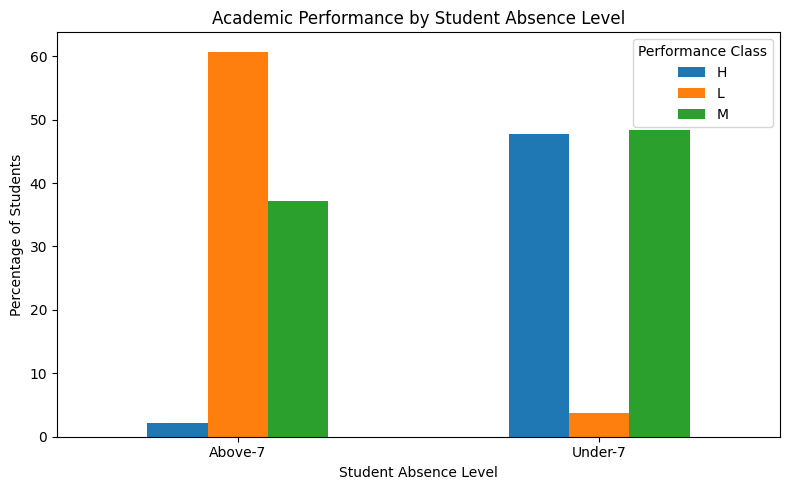

In [19]:
absence_class = pd.crosstab(
      df["StudentAbsenceDays"],
          df["Class"],
              normalize="index"
              ) * 100

absence_class.plot(
    kind="bar",
        figsize=(8, 5)
        )

plt.title("Academic Performance by Student Absence Level")
plt.xlabel("Student Absence Level")
plt.ylabel("Percentage of Students")
plt.xticks(rotation=0)
plt.legend(title="Performance Class")
plt.tight_layout()
plt.show()

### Observation

The performance distribution differs substantially between the two absence categories. Students in the Under-7 absence group have a much larger proportion of H students, while the Above-7 group has a much larger proportion of L students.

## 9. Data Preparation

Before applying machine learning algorithms, the dataset is separated into input features and the target variable.

The `Class` column is used as the target because it represents the academic performance category that the models are required to predict. All remaining columns are treated as input features.

In [20]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (480, 16)
Target shape: (480,)


### Observation

The dataset contains 16 input features and one target variable. The 480 observations are therefore represented by 16 predictor variables that will be used to predict the student's academic performance class.

### Identification of Numerical and Categorical Features

The input variables are separated into numerical and categorical groups. This distinction is necessary because the two types of variables require different preprocessing techniques before they can be supplied to the machine learning models.

In [21]:
numeric_features = X.select_dtypes(include=["int64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion']

Categorical features:
['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID', 'SectionID', 'Topic', 'Semester', 'Relation', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays']


### Observation

The dataset contains four numerical features and twelve categorical features. These two groups will therefore require different preprocessing steps before model training.

## 10. Train-Test Split

The dataset is divided into training and testing subsets so that the models can be trained on one portion of the data and evaluated on observations that were not used during training.

An 80:20 split is used. Stratification is applied to maintain the distribution of the three academic performance classes in both subsets.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
        y,
            test_size=0.20,
                random_state=42,
                    stratify=y
                    )

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (384, 16)
Testing features: (96, 16)
Training target: (384,)
Testing target: (96,)


### Observation

The split produces 384 training observations and 96 testing observations. The test set is kept separate and is used only for evaluating the trained models.

## 11. Data Preprocessing

The machine learning models require the input data to be represented in a suitable numerical format.

Categorical variables are converted into numerical form using one-hot encoding, while the numerical variables are standardized using `StandardScaler`. The preprocessing is fitted using the training data and then applied to both the training and testing sets.

In [24]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

preprocessor_scaled = ColumnTransformer(
    transformers=[
            ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
                    ("numerical", StandardScaler(), numeric_features)
                        ]
                        )

In [35]:
X_train_processed = preprocessor_scaled.fit_transform(X_train)
X_test_processed = preprocessor_scaled.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (384, 72)
Processed testing shape: (96, 72)


### Observation

After preprocessing, the original 16 input features are represented by 72 processed features. The training set contains 384 observations and the testing set contains 96 observations.

## 12. Logistic Regression Model

Logistic Regression is used as the first classification model. It provides a baseline for predicting the three academic performance classes using the prepared feature set.

The model is trained using the processed training data and is then used to predict the performance class of the test observations.

In [31]:
logistic_model = LogisticRegression(
      max_iter=1000,
          random_state=42
          )

In [36]:
logistic_model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Observation

The Logistic Regression model was successfully trained using the processed training dataset.

### Predictions

After training, the Logistic Regression model is used to generate predictions for the unseen test observations.

In [37]:
y_pred = logistic_model.predict(X_test_processed)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
['M' 'L' 'H' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'H' 'M' 'M' 'H' 'L' 'M'
 'H' 'M']


### Model Evaluation

The Logistic Regression model is evaluated using accuracy, a classification report, and a confusion matrix. These measures provide both an overall performance score and class-specific information.

In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.75
Accuracy (%): 75.0


### Classification Report

The classification report provides precision, recall, and F1-score for each academic performance class.

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           H       0.77      0.69      0.73        29
           L       0.83      0.80      0.82        25
           M       0.70      0.76      0.73        42

    accuracy                           0.75        96
   macro avg       0.77      0.75      0.76        96
weighted avg       0.75      0.75      0.75        96



### Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for each academic performance class and helps identify which classes are most frequently confused.

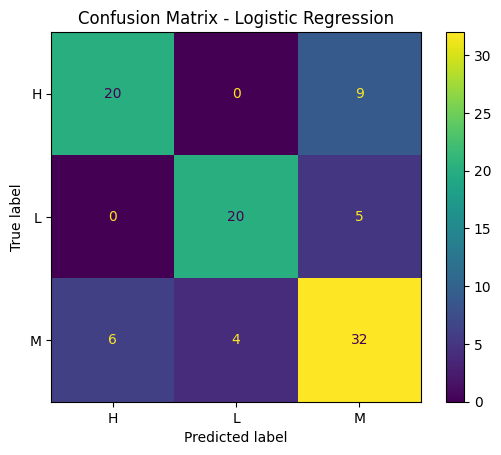

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=["H", "L", "M"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["H", "L", "M"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Observation

The confusion matrix shows that the model correctly classified a large proportion of students in each performance class. The largest number of correct predictions is observed for the M class, while some H and M students are classified incorrectly.

## 13. Decision Tree Model

A Decision Tree classifier is developed as a second machine learning approach. Unlike Logistic Regression, the Decision Tree can represent decision rules through a tree-based structure.

The same processed training and testing data are used so that the performance of the two models can be compared fairly.

In [33]:
decision_tree = DecisionTreeClassifier(
    random_state=42
    )

In [41]:
decision_tree.fit(X_train_processed, y_train)

DecisionTreeClassifier(random_state=42)

In [42]:
y_pred_tree = decision_tree.predict(X_test_processed)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

Decision Tree Accuracy: 0.6354166666666666


### Observation

The Decision Tree achieved an accuracy of approximately 63.54% on the test dataset. Its performance is lower than the Logistic Regression model, indicating that Logistic Regression provides a stronger result for this dataset under the current settings.

### Decision Tree Evaluation

The Decision Tree is evaluated using the same metrics used for Logistic Regression: accuracy, precision, recall, F1-score, and a confusion matrix.

In [43]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           H       0.64      0.72      0.68        29
           L       0.66      0.76      0.70        25
           M       0.62      0.50      0.55        42

    accuracy                           0.64        96
   macro avg       0.64      0.66      0.64        96
weighted avg       0.63      0.64      0.63        96



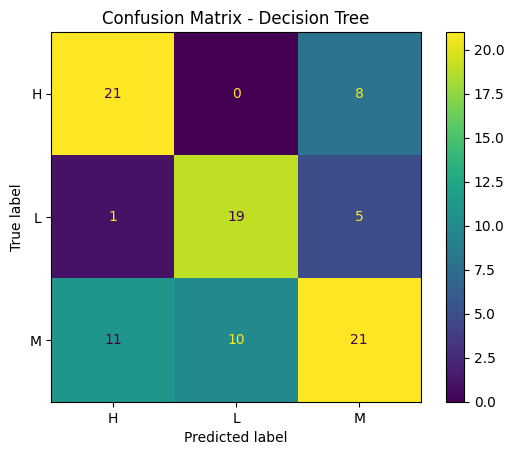

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_tree = confusion_matrix(
    y_test,
    y_pred_tree,
    labels=["H", "L", "M"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["H", "L", "M"]
)

disp.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

### Observation

The confusion matrix shows that the Decision Tree makes a noticeable number of incorrect predictions across the three performance classes, which is consistent with its lower overall accuracy.

## 14. Model Comparison

The two classification models are compared using their test-set accuracy. Comparing the models on the same testing data provides a straightforward way to identify which approach performed better for this dataset.

In [45]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [0.75, 0.6354166666666666]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.750000
1,Decision Tree,0.635417


### Accuracy Comparison

A bar chart is used to visualize the difference in test-set accuracy between Logistic Regression and the Decision Tree.

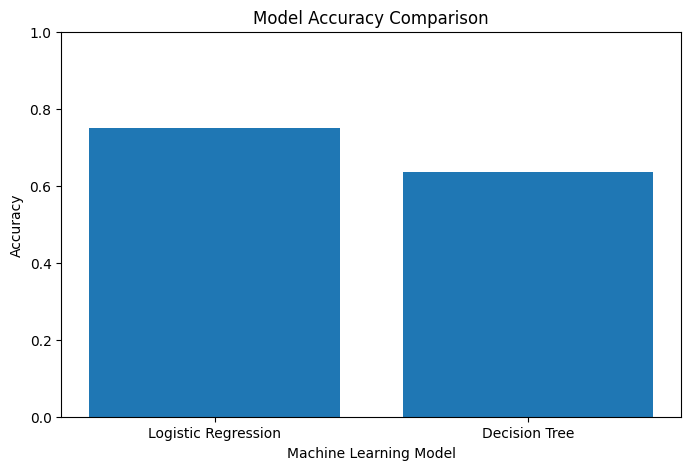

In [46]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

### Observation

The accuracy comparison shows that Logistic Regression achieved 75% accuracy, while the Decision Tree achieved approximately 63.54%. Therefore, Logistic Regression performed better on the test dataset.

## 15. Results and Interpretation

The machine learning models were evaluated using the test dataset to compare their classification performance.

Logistic Regression achieved an accuracy of 75%, while the Decision Tree achieved an accuracy of approximately 63.54%. Based on accuracy, Logistic Regression performed better on this dataset.

The classification report for Logistic Regression also shows an overall weighted F1-score of 0.75. Among the three performance classes, the model performed best for the Low (L) class, with a precision of 0.83, recall of 0.80, and F1-score of 0.82.

The results suggest that the participation and academic-related features in the dataset contain useful information for predicting students' academic performance. However, the model is not perfect, as some students are still classified into the wrong performance category.

Overall, Logistic Regression was selected as the better-performing model among the two models tested because it achieved higher accuracy on the test dataset.

## 16. Conclusion

This project analysed the Student Academic Performance dataset and used machine learning to predict students' academic performance classes. The analysis included data inspection, exploratory analysis, feature preparation, categorical encoding, numerical scaling, and model evaluation.

Two classification models were tested: Logistic Regression and Decision Tree. Logistic Regression achieved an accuracy of 75% on the test dataset, while the Decision Tree achieved approximately 63.54%. Based on these results, Logistic Regression performed better among the two models evaluated.

The exploratory analysis also showed noticeable differences in student participation measures and performance distributions across some categorical groups. These patterns suggest that the features in the dataset provide useful information for classifying academic performance.

Overall, the project demonstrates how exploratory data analysis and machine learning can be combined to study student academic performance and build a predictive classification model. Further improvement could be explored by testing additional algorithms, tuning model parameters, and evaluating the models using additional validation techniques.